# Optimizers: How a Model Finds Better Answers

Imagine you are standing on a foggy hill and want to reach the lowest valley. You cannot see the whole hill, but you can feel which direction slopes downward under your feet. You take a step downhill, check again, and repeat. A machine-learning model does something similar: its **optimizer** changes the model's adjustable numbers to make its **loss** smaller.

This notebook starts from the beginning. It explains gradient descent, batch/stochastic/mini-batch updates, Momentum with SGD, and AdaGrad. Every formula is explained in words, examples use small numbers, diagrams are generated in the notebook, and working NumPy implementations are included. “Better” here means lower training loss; a model still needs validation data to check that it works on new examples.

## 1. The ingredients

A model has adjustable settings called **parameters** or **weights**. We collect them into $\\theta$ (theta). For example, a straight-line model can be written as:

$$
\hat{y} = wx + b
$$

Here, $w$ is the slope and $b$ is the intercept. The model makes predictions $\\hat{y}$, and a loss function scores how far those predictions are from the correct answers. The loss across the training examples is written $J(\\theta)$.

An **optimizer** is the rule that decides how to change $\\theta$ using information about the loss. The **gradient** $\\nabla J(\\theta)$ is a collection of slopes: it tells how the loss changes when each parameter changes a little. Think of it as an arrow pointing uphill. To go downhill, we step in the opposite direction.

The simplest update is:

$$
\theta_{\text{new}} = \theta_{\text{old}} - \eta \nabla J(\theta_{\text{old}})
$$

- $\\theta$: the model's adjustable parameters.
- $J$: the loss we are trying to reduce.
- $\\nabla J$: the direction and steepness of the uphill slope.
- $\\eta$ (eta): the **learning rate**, or step size.
- Minus sign: walk opposite the uphill direction, toward lower loss.

If the step size is tiny, learning can be very slow. If it is too large, the model can jump past the valley, bounce around, or even move to a worse place. The learning rate is an important setting we choose.

### A tiny example

Suppose the loss is $J(w)=(w-3)^2$, so the best value is $w=3$ and the loss is zero there. Its gradient is $2(w-3)$. Starting at $w=0$ with learning rate $0.1$:

$$
w_{\\text{new}} = 0 - 0.1[2(0-3)] = 0.6
$$

The weight moved from 0 toward 3. Repeating this update moves it closer to 3. The first picture shows a hilly loss surface and a path from a starting point toward its low spot. The axes are two example parameters; real neural networks can have millions.


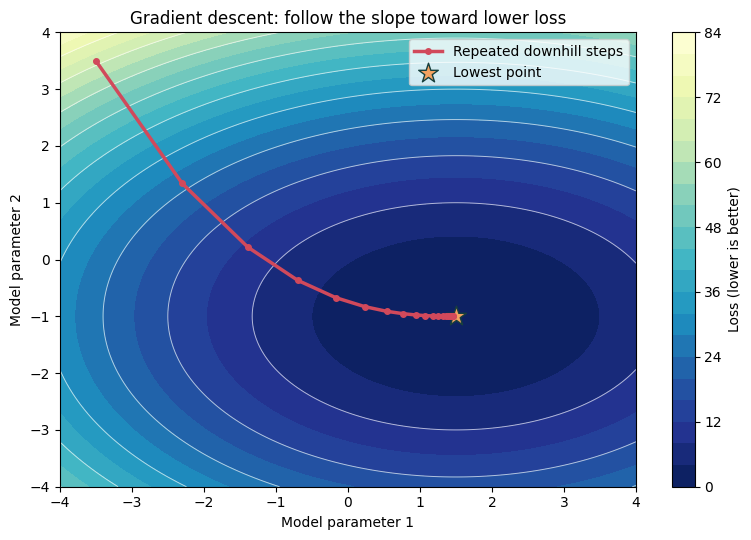

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A tilted bowl gives us a simple two-parameter loss surface to walk down.
def bowl_loss(point):
    x_value, y_value = point
    return (x_value - 1.5) ** 2 + 2 * (y_value + 1.0) ** 2

def bowl_gradient(point):
    x_value, y_value = point
    return np.array([2 * (x_value - 1.5), 4 * (y_value + 1.0)])

path = [np.array([-3.5, 3.5], dtype=float)]
learning_rate = 0.12
for _ in range(18):
    path.append(path[-1] - learning_rate * bowl_gradient(path[-1]))
path = np.array(path)

x_grid, y_grid = np.meshgrid(np.linspace(-4, 4, 220), np.linspace(-4, 4, 220))
loss_grid = (x_grid - 1.5) ** 2 + 2 * (y_grid + 1.0) ** 2
figure, axis = plt.subplots(figsize=(8, 5.5))
contours = axis.contourf(x_grid, y_grid, loss_grid, levels=24, cmap="YlGnBu_r")
axis.contour(x_grid, y_grid, loss_grid, levels=12, colors="white", alpha=0.65, linewidths=0.7)
axis.plot(path[:, 0], path[:, 1], "o-", color="#d1495b", linewidth=2.5, markersize=4, label="Repeated downhill steps")
axis.scatter([1.5], [-1.0], marker="*", s=220, color="#f4a261", edgecolor="#173f3c", label="Lowest point")
axis.set(title="Gradient descent: follow the slope toward lower loss", xlabel="Model parameter 1", ylabel="Model parameter 2")
axis.legend(frameon=True)
figure.colorbar(contours, ax=axis, label="Loss (lower is better)")
figure.tight_layout()
plt.show()

## 2. Three ways to choose the examples for an update

A training set contains examples (for example, pictures and their labels). An optimizer estimates the slope of the loss from examples, then updates the model. The main difference between Batch Gradient Descent, Stochastic Gradient Descent (SGD), and Mini-Batch Gradient Descent is **how many training examples are used to calculate one update**.

Suppose there are $N$ training examples, and example $i$ has loss $L_i(\\theta)$. The gradient from one example is $g_i=\\nabla_\\theta L_i(\\theta)$. All three methods use the same basic idea: estimate an uphill direction and subtract a step in that direction. They differ in how many examples go into that estimate.

### 2.1 Batch Gradient Descent (Vanilla Gradient Descent)

**Definition:** Use the entire training set to calculate one gradient and make one update. “Vanilla” means the plain/basic version, not a special flavor.

For $N$ examples, first calculate the average training loss:

$$
J(\\theta)=\\frac{1}{N}\\sum_{i=1}^{N}L_i(\\theta)
$$

Then update once:

$$
\\theta_{t+1}=\\theta_t-\\eta\\nabla_\\theta J(\\theta_t)
=\\theta_t-\\eta\\frac{1}{N}\\sum_{i=1}^{N}\\nabla_\\theta L_i(\\theta_t)
$$

**Process:** (1) Start with model parameters. (2) Make predictions for all training examples. (3) calculate all their losses. (4) Average their gradients. (5) Take one update. (6) Repeat until the stopping rule says to stop.

**Small example:** if three examples give gradients $[2, 0, -1]$ for a parameter, their average gradient is $(2+0-1)/3=1/3$. With learning rate $0.3$, the parameter changes by $-0.3(1/3)=-0.1$.

**Advantages:** the gradient uses all examples, so it is usually a steady, repeatable direction for the current model. It can work well for small datasets and gives a clear full-dataset update.

**Limitations:** every update requires looking at the whole dataset. For large datasets, this can be slow and memory-heavy, and the model cannot update until all examples have been processed. If the loss surface has many valleys, a steady gradient can settle into a nearby valley rather than the very lowest possible point.

**Picture:** each colored mark below is one example's gradient. Batch Gradient Descent averages them into one update arrow.


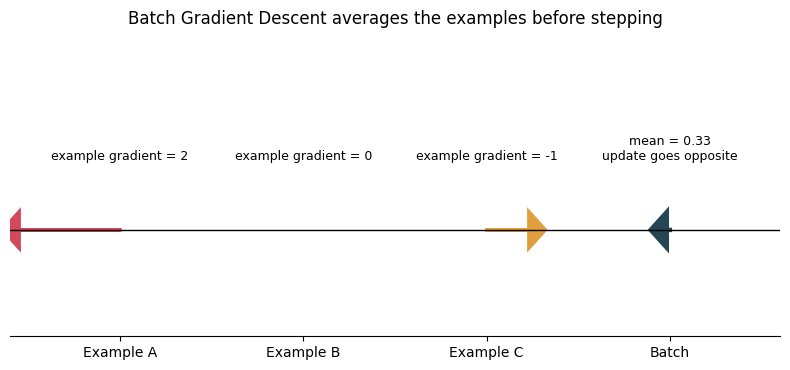

In [3]:
# Picture 2: individual example gradients and their batch average.
example_gradients = np.array([2.0, 0.0, -1.0])
mean_gradient = example_gradients.mean()
figure, axis = plt.subplots(figsize=(8, 3.8))
colors = ["#d1495b", "#287271", "#e09f3e"]
for index, gradient in enumerate(example_gradients):
    axis.arrow(index, 0, -0.32 * gradient, 0, head_width=0.12, head_length=0.09, length_includes_head=True, color=colors[index], linewidth=2.5)
    axis.text(index, 0.23, f"example gradient = {gradient:g}", ha="center", fontsize=9)
axis.arrow(3, 0, -0.32 * mean_gradient, 0, head_width=0.12, head_length=0.09, length_includes_head=True, color="#264653", linewidth=3)
axis.text(3, 0.23, f"mean = {mean_gradient:.2f}\nupdate goes opposite", ha="center", fontsize=9)
axis.axhline(0, color="black", linewidth=1)
axis.set_xlim(-0.6, 3.6)
axis.set_ylim(-0.35, 0.65)
axis.set_yticks([])
axis.set_xticks([0, 1, 2, 3], ["Example A", "Example B", "Example C", "Batch"])
axis.set_title("Batch Gradient Descent averages the examples before stepping")
axis.spines[["left", "right", "top"]].set_visible(False)
figure.tight_layout()
plt.show()

### 2.2 Stochastic Gradient Descent (SGD)

**Definition:** Use just **one randomly selected training example** to calculate each update. “Stochastic” means that there is randomness: the chosen example can change from step to step. In practice, examples are shuffled so the model does not always see them in the same order.

For one selected example $i$:

$$
\\theta_{t+1}=\\theta_t-\\eta\\nabla_\\theta L_i(\\theta_t)
$$

**Process:** shuffle the examples; take one example; calculate its prediction, loss, and gradient; update the parameters; move to another example; repeat. A pass through all training examples is still called an **epoch**, even though SGD has made many updates during that pass.

**Small example:** suppose the chosen example gives gradient $g_i=2$ for a weight and the learning rate is $0.1$. The weight changes by $-0.1(2)=-0.2$. The next example may point a different way, so the path wiggles rather than moving smoothly.

**Advantages:** updates are cheap and frequent, so learning can begin quickly. Random variation can help the parameters move out of some shallow traps or flat regions.

**Limitations:** each update is noisy and the loss can bounce around. The model may not settle exactly at a minimum unless the learning rate is adjusted or training is stopped appropriately. Randomness makes the path and final result vary between runs.

**Picture:** the noisy red path is built from one-example-at-a-time gradients; the smooth line shows the general direction toward the low point.


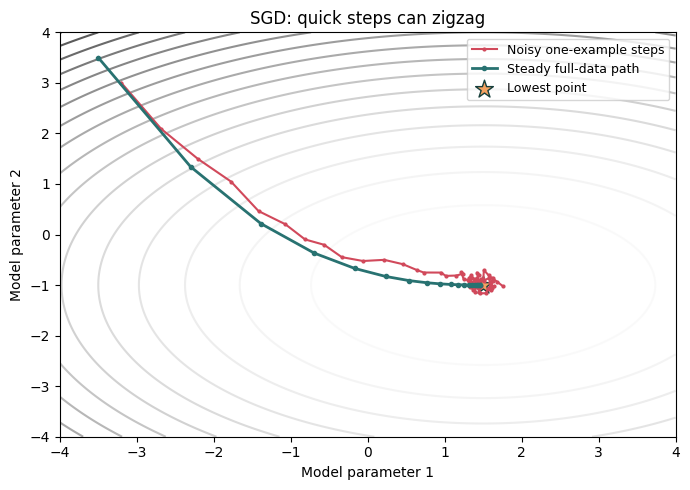

In [4]:
# Picture 3: single-example gradients make an SGD path noisy.
rng = np.random.default_rng(7)
sgd_path = [np.array([-3.2, 3.0], dtype=float)]
for _ in range(65):
    current = sgd_path[-1]
    noisy_gradient = bowl_gradient(current) + rng.normal(0, [1.0, 1.8])
    sgd_path.append(current - 0.055 * noisy_gradient)
sgd_path = np.array(sgd_path)
figure, axis = plt.subplots(figsize=(7, 5))
axis.contour(x_grid, y_grid, loss_grid, levels=18, cmap="Greys", alpha=0.75)
axis.plot(sgd_path[:, 0], sgd_path[:, 1], ".-", color="#d1495b", linewidth=1.5, markersize=4, label="Noisy one-example steps")
axis.plot(path[:, 0], path[:, 1], "o-", color="#287271", linewidth=2, markersize=3, label="Steady full-data path")
axis.scatter([1.5], [-1.0], marker="*", s=180, color="#f4a261", edgecolor="#173f3c", label="Lowest point")
axis.set(title="SGD: quick steps can zigzag", xlabel="Model parameter 1", ylabel="Model parameter 2")
axis.legend(frameon=True, fontsize=9)
figure.tight_layout()
plt.show()

### 2.3 Mini-Batch Gradient Descent

**Definition:** Use a small group of examples, called a **mini-batch**, for each gradient and update. It sits between full-batch (all examples) and SGD (one example). Mini-batches are the usual choice in deep-learning training.

For a batch $B_t$ with $b$ examples:

$$
g_t=\\frac{1}{b}\\sum_{i\\in B_t}\\nabla_\\theta L_i(\\theta_t),\\qquad
\\theta_{t+1}=\\theta_t-\\eta g_t
$$

Here $b$ is the **batch size**. For example, with 1000 training examples and a batch size of 100, there are 10 updates in one epoch (assuming all examples are used once and the final batch is full; some datasets need a smaller final batch).

**Process:** shuffle the dataset; split it into mini-batches; calculate the average gradient for one mini-batch; update the parameters; continue through the batches; repeat for more epochs.

**Advantages:** it makes more frequent updates than full-batch while averaging away some of SGD's noise. It can use vectorized hardware efficiently and is a practical balance of speed, memory, and update stability.

**Limitations:** batch size is another setting to choose. A batch that is too large needs more memory and makes fewer updates per epoch; a very small batch can be noisy. The best size depends on the model, hardware, and data.

**Picture:** each colored group is averaged separately, creating one update per mini-batch.


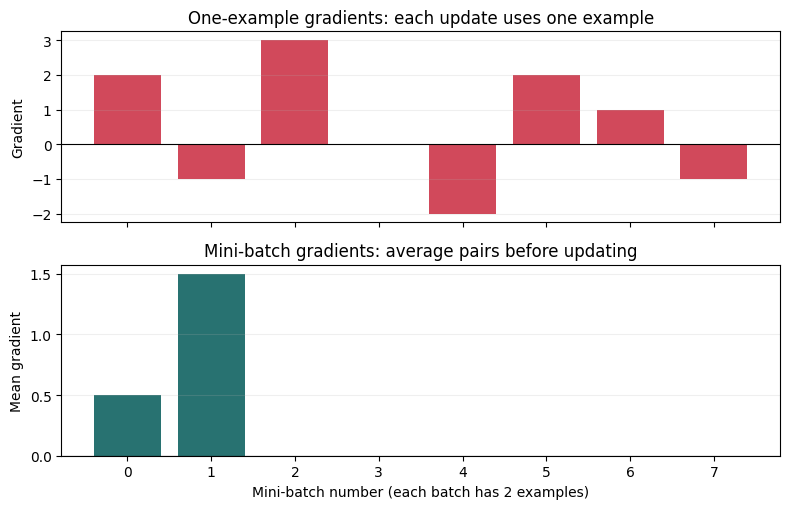

In [5]:
# Picture 4: mini-batch averages are less noisy than one example at a time.
example_gradient_stream = np.array([2.0, -1.0, 3.0, 0.0, -2.0, 2.0, 1.0, -1.0])
batch_size = 2
mini_batch_means = np.array([
    example_gradient_stream[start:start + batch_size].mean()
    for start in range(0, len(example_gradient_stream), batch_size)
])
figure, axes = plt.subplots(2, 1, figsize=(8, 5.2), sharex=True)
axes[0].bar(np.arange(len(example_gradient_stream)), example_gradient_stream, color="#d1495b")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Gradient")
axes[0].set_title("One-example gradients: each update uses one example")
axes[1].bar(np.arange(len(mini_batch_means)), mini_batch_means, color="#287271")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Mean gradient")
axes[1].set_xlabel("Mini-batch number (each batch has 2 examples)")
axes[1].set_title("Mini-batch gradients: average pairs before updating")
for axis in axes:
    axis.grid(axis="y", alpha=0.2)
figure.tight_layout()
plt.show()

### Compare the three methods

| Method | Examples used for one update | Update pattern | Memory and work per update |
|---|---|---|---|
| Batch Gradient Descent | Entire training set | Steady, one update after all examples | High for a large dataset |
| Stochastic Gradient Descent | One example | Noisy, many quick updates | Low |
| Mini-Batch Gradient Descent | A small group | Some noise, efficient updates | Moderate and adjustable |

An **epoch** is one full pass over the training set. Batch Gradient Descent typically takes one update per epoch; SGD takes one update per example; mini-batch takes about $N/b$ updates per epoch. If data are shuffled, each mini-batch usually contains a different group next epoch. In deep learning, “SGD” is also often used as the name of an optimizer that actually processes mini-batches; always check the batch size in the training code.

## 3. Momentum with SGD

### The idea and physics picture

Momentum helps ordinary gradient descent keep moving in a useful direction. Imagine a ball rolling down a slope: it builds **velocity** as it moves, and it does not instantly forget its previous direction at every small bump. In optimization, the “ball” is a point representing the model parameters, the hillside is the loss surface, and the slope is the gradient.

A plain SGD step responds only to the current gradient. Momentum remembers a running average of recent gradients. This often reduces zigzagging in a long valley and can speed progress along a consistent direction. It does not mean physical mass or real-world energy is being simulated exactly; the ball is an intuition for the update rule.

**Picture:** compare the zigzag path without momentum to the smoother path when recent downhill directions are carried forward.


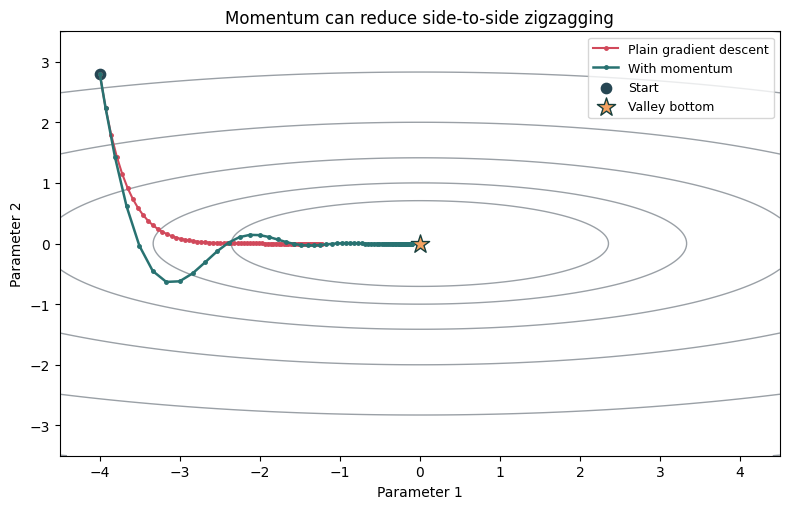

In [9]:
# Picture 5: momentum smooths alternating gradients in a narrow valley.
def narrow_valley_gradient(point):
    x_value, y_value = point
    return np.array([0.18 * x_value, 2.0 * y_value])

def follow_valley(use_momentum, steps=65, step_size=0.1, momentum_rate=0.65):
    current = np.array([-4.0, 2.8], dtype=float)
    velocity = np.zeros(2)
    points = [current.copy()]
    for _ in range(steps):
        gradient = narrow_valley_gradient(current)
        if use_momentum:
            velocity = momentum_rate * velocity + gradient
            current = current - step_size * velocity
        else:
            current = current - step_size * gradient
        points.append(current.copy())
    return np.array(points)

x_valley, y_valley = np.meshgrid(np.linspace(-4.5, 4.5, 220), np.linspace(-3.5, 3.5, 220))
valley_loss = 0.09 * x_valley**2 + y_valley**2
plain_path = follow_valley(False)
momentum_path = follow_valley(True)
figure, axis = plt.subplots(figsize=(8, 5.2))
axis.contour(x_valley, y_valley, valley_loss, levels=[0.5, 1, 2, 4, 8, 14], colors="#9aa0a6", linewidths=1)
axis.plot(plain_path[:, 0], plain_path[:, 1], "o-", color="#d1495b", markersize=2.5, linewidth=1.5, label="Plain gradient descent")
axis.plot(momentum_path[:, 0], momentum_path[:, 1], "o-", color="#287271", markersize=2.5, linewidth=1.8, label="With momentum")
axis.scatter([-4], [2.8], color="#264653", s=55, label="Start")
axis.scatter([0], [0], marker="*", color="#f4a261", edgecolor="#173f3c", s=190, label="Valley bottom")
axis.set(title="Momentum can reduce side-to-side zigzagging", xlabel="Parameter 1", ylabel="Parameter 2")
axis.legend(frameon=True, fontsize=9)
figure.tight_layout()
plt.show()

### Momentum formula, built one piece at a time

Let $g_t$ be the current gradient and $v_t$ be the remembered direction, called the **velocity**. Momentum combines the new gradient with part of the old velocity:

$$
v_t=\\beta v_{t-1}+g_t
$$

Then parameters move opposite the velocity:

$$
\\theta_{t+1}=\\theta_t-\\eta v_t
$$

- $\\beta$ (beta) is the momentum setting, often chosen between 0 and 1. A larger beta remembers more of the past.
- $v_0$ commonly starts at zero.
- $\\eta$ is the learning rate.

**Where this comes from:** start with a weighted memory of the gradients: $v_t=g_t+\\beta g_{t-1}+\\beta^2g_{t-2}+\\cdots$. The recursive rule $v_t=\\beta v_{t-1}+g_t$ builds that memory one step at a time without keeping the whole history. If gradients keep pointing in roughly the same direction, the remembered velocity grows. If gradients alternate side to side, some of them cancel, reducing zigzagging.

Some textbooks/frameworks define velocity as $v_t=\\beta v_{t-1}+(1-\\beta)g_t$ instead. That version rescales the average and may pair with a different learning-rate convention. The two are related but their numeric settings are not directly identical; follow the chosen library's definition.

### Momentum in NumPy

This small function performs one momentum update. Real neural networks use automatic differentiation to calculate `gradient`; here it is supplied to the function.


In [7]:
def momentum_step(parameters, gradient, velocity, learning_rate=0.01, momentum=0.9):
    """Return updated parameters and velocity for one Momentum step."""
    velocity = momentum * velocity + gradient
    parameters = parameters - learning_rate * velocity
    return parameters, velocity

# A one-number demonstration: keep the same slope for three steps.
weight = np.array([2.0])
velocity = np.zeros_like(weight)
for _ in range(3):
    weight, velocity = momentum_step(weight, np.array([1.0]), velocity)
print("Weight after three momentum updates:", weight[0])

Weight after three momentum updates: 1.9439000000000002


## 4. AdaGrad (Adaptive Gradient Algorithm)

### The idea and a picture in your head

AdaGrad changes the step size **separately for each parameter**. If one parameter has repeatedly received large gradients, AdaGrad makes its future steps smaller. If another parameter has received smaller gradients, its steps can stay comparatively larger. This can be helpful when features have very different scales or some features appear only occasionally.

Imagine walking across a mountain where one direction is very steep and another is gently sloped. A single step size can be too large for the steep direction but too small for the gentle one. AdaGrad keeps a separate running record for each direction, then scales each direction's step. The records only grow, so the effective step sizes generally get smaller over time.

**Picture:** the left panel compares differently scaled directions; the right panel shows how AdaGrad's effective learning rate shrinks as gradient history accumulates.


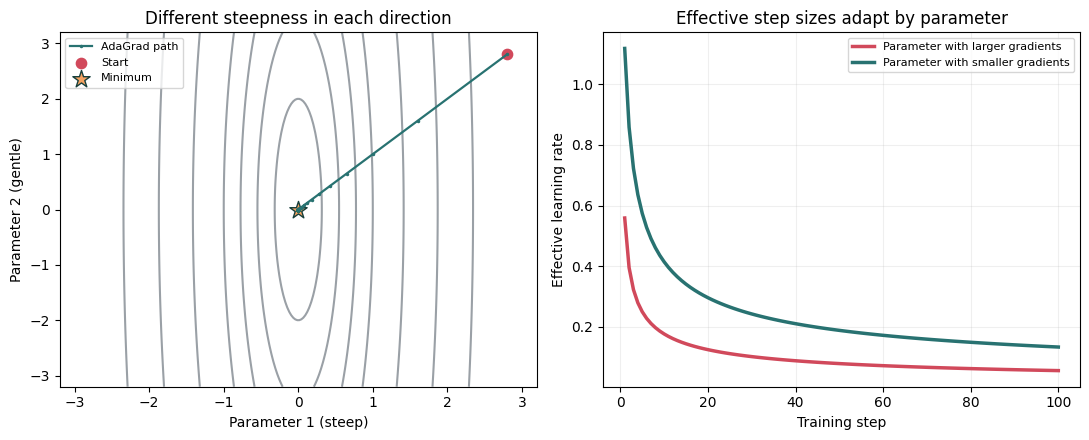

In [10]:
# Picture 6: a steep and a gentle direction need different step scales.
def scaled_bowl_gradient(point):
    x_value, y_value = point
    return np.array([20.0 * x_value, 0.5 * y_value])

def follow_adagrad(start, steps=90, learning_rate=1.2, epsilon=1e-8):
    current = np.array(start, dtype=float)
    squared_gradient_sum = np.zeros_like(current)
    points = [current.copy()]
    for _ in range(steps):
        gradient = scaled_bowl_gradient(current)
        squared_gradient_sum += gradient**2
        current = current - learning_rate * gradient / (np.sqrt(squared_gradient_sum) + epsilon)
        points.append(current.copy())
    return np.array(points)

x_scaled, y_scaled = np.meshgrid(np.linspace(-3.2, 3.2, 240), np.linspace(-3.2, 3.2, 240))
scaled_loss = 10.0 * x_scaled**2 + 0.25 * y_scaled**2
adagrad_path = follow_adagrad([2.8, 2.8])
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].contour(x_scaled, y_scaled, scaled_loss, levels=[1, 3, 6, 10, 20, 35, 55], colors="#9aa0a6")
axes[0].plot(adagrad_path[:, 0], adagrad_path[:, 1], ".-", color="#287271", linewidth=1.6, markersize=3, label="AdaGrad path")
axes[0].scatter([2.8], [2.8], color="#d1495b", s=55, label="Start")
axes[0].scatter([0], [0], marker="*", color="#f4a261", edgecolor="#173f3c", s=170, label="Minimum")
axes[0].set(title="Different steepness in each direction", xlabel="Parameter 1 (steep)", ylabel="Parameter 2 (gentle)")
axes[0].legend(fontsize=8)

steps_axis = np.arange(1, 101)
# Accumulated squared-gradient histories grow, so both effective rates shrink.
history = np.vstack([np.linspace(0.8, 80, len(steps_axis)), np.linspace(0.2, 14, len(steps_axis))])
base_rate = 0.5
rate_one = base_rate / np.sqrt(history[0] + 1e-8)
rate_two = base_rate / np.sqrt(history[1] + 1e-8)
axes[1].plot(steps_axis, rate_one, color="#d1495b", linewidth=2.5, label="Parameter with larger gradients")
axes[1].plot(steps_axis, rate_two, color="#287271", linewidth=2.5, label="Parameter with smaller gradients")
axes[1].set(title="Effective step sizes adapt by parameter", xlabel="Training step", ylabel="Effective learning rate")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)
figure.tight_layout()
plt.show()

### AdaGrad formula and derivation

For parameter number $j$, let $g_{t,j}$ be its gradient at step $t$. AdaGrad stores the sum of squared gradients for that parameter:

$$
G_{t,j}=G_{t-1,j}+g_{t,j}^2=\\sum_{k=1}^{t}g_{k,j}^2
$$

Squaring makes positive and negative gradients add to the history instead of canceling. The history is kept **separately for each parameter**. In vector notation, the square, sum, square root, and division below all happen coordinate by coordinate.

AdaGrad begins with the ordinary gradient step, then divides each coordinate by the square root of its accumulated squared-gradient history:

$$
\\theta_{t+1,j}=\\theta_{t,j}-\\frac{\\eta}{\\sqrt{G_{t,j}}+\\epsilon}g_{t,j}
$$

This is often written using a per-coordinate learning rate:

$$
\\alpha_{t,j}=\\frac{\\eta}{\\sqrt{G_{t,j}}+\\epsilon},\\qquad
\\theta_{t+1,j}=\\theta_{t,j}-\\alpha_{t,j}g_{t,j}
$$

- $\\eta$ is the starting/base learning rate.
- $G_{t,j}$ is the accumulated squared-gradient total for parameter $j$.
- $\\alpha_{t,j}$ is the effective learning rate for that parameter at step $t$.
- $\\epsilon$ is a tiny positive number, such as $10^{-8}$, to prevent division by zero.

**Why does the step shrink?** $G_{t,j}$ only stays the same or increases. Its square root therefore grows or stays the same, so $\\alpha_{t,j}$ usually shrinks. A parameter with large past gradients gets a smaller effective step; one with smaller or rarer gradients gets a relatively larger step.

**Small example:** take $\\eta=0.1$, $\\epsilon=0$, and a first gradient of 2. Then $G_1=2^2=4$, and the effective learning rate is $\\alpha_1=0.1/\\sqrt{4}=0.05$. The parameter changes by $-0.05(2)=-0.1$. With a smaller first gradient of 0.5, its history is $0.25$, its effective rate is $0.2$, and its change is $-0.2(0.5)=-0.1$. In this first-step example both changes have the same size; later steps depend on each parameter's own history.

### AdaGrad in NumPy

The function below keeps an accumulator array with the same shape as the parameters, so each parameter gets its own history and effective learning rate. For a real model, supply gradients calculated from the current mini-batch.


In [11]:
def adagrad_step(parameters, gradient, squared_gradient_sum, learning_rate=0.1, epsilon=1e-8):
    """Return updated parameters and per-parameter squared-gradient history."""
    squared_gradient_sum = squared_gradient_sum + gradient**2
    effective_learning_rate = learning_rate / (np.sqrt(squared_gradient_sum) + epsilon)
    parameters = parameters - effective_learning_rate * gradient
    return parameters, squared_gradient_sum, effective_learning_rate

# Two parameters receive different gradients and therefore different rates.
parameters = np.array([1.0, 1.0])
squared_gradient_sum = np.zeros_like(parameters)
parameters, squared_gradient_sum, effective_rate = adagrad_step(
    parameters, np.array([2.0, 0.5]), squared_gradient_sum
)
print("Updated parameters:", parameters)
print("Effective rates:", effective_rate)

Updated parameters: [0.9 0.9]
Effective rates: [0.05 0.2 ]


## 5. Choosing and using an optimizer

| Method | Main idea | Often helpful when | Main thing to watch |
|---|---|---|---|
| Batch Gradient Descent | Average gradients over all training examples | Dataset is small and a steady full-data direction is useful | One update can be expensive on a large dataset |
| SGD | Update from one example | You want very frequent, inexpensive updates | Noisy path and learning-rate sensitivity |
| Mini-Batch Gradient Descent | Average a small group, then update | You want an efficient practical balance | Choose a batch size that fits memory and works for the data |
| Momentum with SGD | Carry part of the previous update forward | Gradients point consistently downhill or plain SGD zigzags | Momentum can overshoot; tune learning rate and beta together |
| AdaGrad | Give each parameter its own shrinking step size | Features have different scales or some features are rare | Accumulated history only grows, so steps can become very small |

### A practical training checklist

1. Start with a sensible model, loss function, and mini-batch size; ensure labels and outputs match the loss.
2. Choose a learning rate. If loss repeatedly shoots upward or becomes `NaN`, the rate may be too large or there may be a numerical/data issue. If loss barely moves, it may be too small, though other causes are possible.
3. Track training loss and validation loss. Training loss shows how well the model fits seen examples; validation loss gives a check on examples held out from training.
4. Change one important setting at a time and compare runs on the same validation data.
5. Remember that Momentum and AdaGrad alter the update rule; they do not choose a good model, clean bad data, or guarantee that the model generalizes.

The examples in this notebook use NumPy arrays to make the update rules visible. Libraries such as PyTorch and TensorFlow normally calculate gradients automatically using **automatic differentiation**. In a full training loop, the usual order is: compute predictions, compute loss, calculate gradients, let the optimizer update parameters, and repeat.

## Quick review

- **Optimizer:** a rule for changing model parameters to reduce loss.
- **Gradient:** tells which direction makes loss rise fastest; subtract it to move downhill.
- **Learning rate:** how big a step to take.
- **Batch Gradient Descent:** one update from all examples.
- **SGD:** one update from one example; noisy but frequent.
- **Mini-batch:** one update from a small group; the common deep-learning choice.
- **Momentum:** remembers recent gradient direction, like a rolling ball carrying speed.
- **AdaGrad:** remembers squared gradients and adapts the step size separately for each parameter.
- **Epoch:** one pass through the training dataset; the number of updates in an epoch depends on batch size.

### Check yourself

1. If the loss goes up and down wildly, what setting might you try reducing first?
2. Which method uses the whole dataset for one update?
3. Why does Momentum help on a long, narrow valley?
4. What is AdaGrad's $G_{t,j}$ keeping track of?
5. Does a low training loss alone prove the model will work well on new data?

**Answers:** (1) Try a smaller learning rate, while also checking data and numerical stability. (2) Batch Gradient Descent. (3) It carries useful direction forward and can reduce side-to-side zigzagging. (4) The sum of squared gradients for parameter $j$. (5) No; check validation data to estimate performance on unseen examples.
